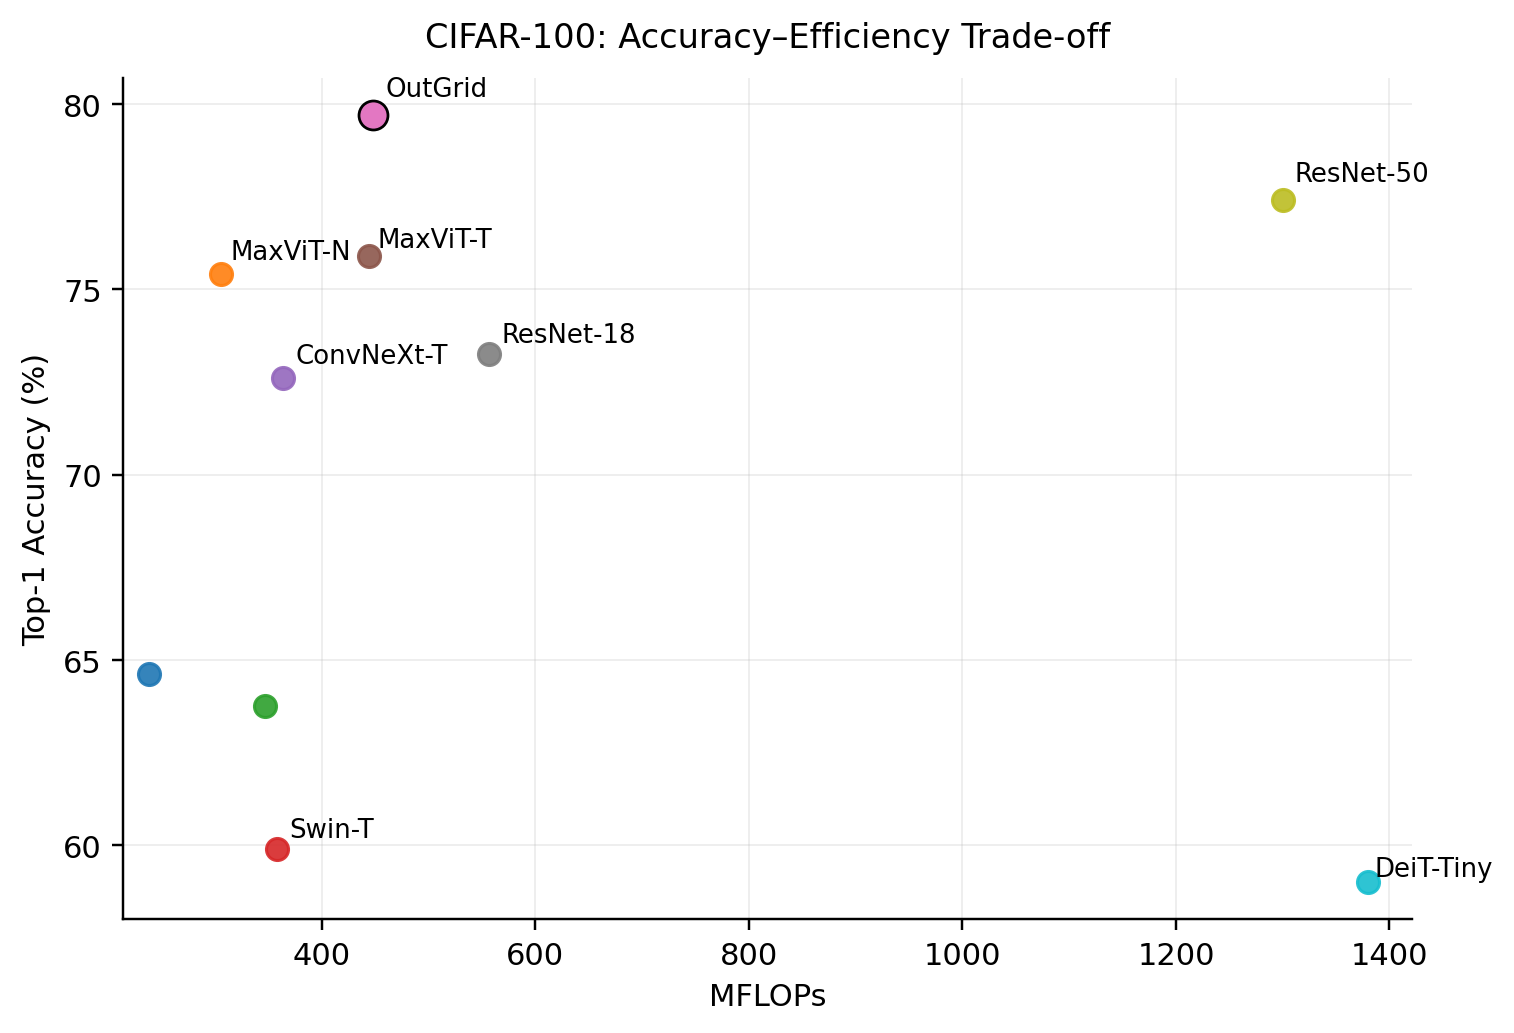

In [3]:
import re
import matplotlib.pyplot as plt

log_path = r"C:\Users\alejo\OneDrive\Escritorio\Pablo\Profesional\Modelaje\Modelos de DL\outlook-grid-vision-transformer\logs\Logs Models Comparisons Cifrar100 100epocs.txt"

header_re = re.compile(r"^-{5,}\s*(.+?)\s*-{5,}$")
top1_re = re.compile(r"top1:\s*([0-9.]+)")
params_re = re.compile(r"model:\s*params=([\d,]+)")
mflops_re = re.compile(r"Compute \(per forward\):\s*([0-9.]+)\s*(M|G)FLOPs")
throughput_re = re.compile(r"throughput:\s*([0-9.]+)\s*imgs/s")

models = []
current = None

with open(log_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        m_header = header_re.match(line)
        if m_header:
            if current and {"top1", "params", "mflops"} <= current.keys():
                models.append(current)
            current = {"model": m_header.group(1).strip()}
            continue

        if not current:
            continue

        m_top1 = top1_re.search(line)
        if m_top1:
            current["top1"] = float(m_top1.group(1))

        m_params = params_re.search(line)
        if m_params:
            current["params"] = int(m_params.group(1).replace(",", ""))

        m_mflops = mflops_re.search(line)
        if m_mflops:
            val = float(m_mflops.group(1))
            unit = m_mflops.group(2)
            current["mflops"] = val * 1000.0 if unit == "G" else val

        m_thr = throughput_re.search(line)
        if m_thr:
            current["throughput"] = float(m_thr.group(1))

if current and {"top1", "params", "mflops"} <= current.keys():
    models.append(current)

models = [m for m in models if {"top1", "params", "mflops"} <= m.keys()]

# ---------------------------
# PRETTY NAMES
# ---------------------------
pretty_name_map = {
    "OutGrid (OURS)": "OutGrid",
    "OutGrid": "OutGrid",
    "Resnet50": "ResNet-50",
    "Resnet18": "ResNet-18",
    "Deit_Tiny": "DeiT-Tiny",
    "Deit_Nano": "DeiT-Nano",
    "efficientnetv2_small": "EffNetV2-S",
    "SwinVit": "Swin-T",
    "CONVEXT": "ConvNeXt-T",
    "MaxVit_Tiny": "MaxViT-T",
    "MaxVit_Nano": "MaxViT-N",
}

for m in models:
    raw = m["model"]
    m["pretty"] = pretty_name_map.get(raw, raw)

# ---------------------------
# SORT FOR CLEANER DRAWING
# ---------------------------
models = sorted(models, key=lambda d: d["mflops"])

# ---------------------------
# PLOT: MFLOPs vs Top-1
# ---------------------------
fig, ax = plt.subplots(figsize=(7.0, 4.8), dpi=220)

# only label the most important models to reduce clutter
label_set = {
    "OutGrid",
    "ResNet-50",
    "ResNet-18",
    "ConvNeXt-T",
    "MaxViT-T",
    "MaxViT-N",
    "DeiT-Tiny",
    "Swin-T",
}

for m in models:
    x = m["mflops"]
    y = m["top1"]
    name = m["pretty"]

    is_ours = "OutGrid" in name

    if is_ours:
        ax.scatter(
            x, y,
            s=90,
            marker="o",
            edgecolors="black",
            linewidths=0.9,
            zorder=4,
            label="OutGrid"
        )
    else:
        ax.scatter(
            x, y,
            s=52,
            alpha=0.9,
            zorder=3
        )

    if name in label_set:
        dx, dy = 6, 5

        # a few manual tweaks to avoid overlaps
        if name == "ResNet-50":
            dx, dy = 4, 6
        elif name == "ResNet-18":
            dx, dy = 4, 4
        elif name == "ConvNeXt-T":
            dx, dy = 4, 5
        elif name == "MaxViT-T":
            dx, dy = 3, 3
        elif name == "MaxViT-N":
            dx, dy = 3, 5
        elif name == "DeiT-Tiny":
            dx, dy = 2, 2
        elif name == "Swin-T":
            dx, dy = 4, 4
        elif name == "OutGrid":
            dx, dy = 4, 6

        ax.annotate(
            name,
            (x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=8.5
        )

# styling
ax.set_xlabel("MFLOPs", fontsize=10)
ax.set_ylabel("Top-1 Accuracy (%)", fontsize=10)
ax.set_title("CIFAR-100: Accuracy–Efficiency Trade-off", fontsize=11, pad=10)

ax.grid(True, alpha=0.22, linewidth=0.6)
ax.set_axisbelow(True)

# cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# tighten limits a bit for nicer composition
xvals = [m["mflops"] for m in models]
yvals = [m["top1"] for m in models]
ax.set_xlim(min(xvals) * 0.9, max(xvals) * 1.03)
ax.set_ylim(min(yvals) - 1.0, max(yvals) + 1.0)

plt.tight_layout()
plt.show()

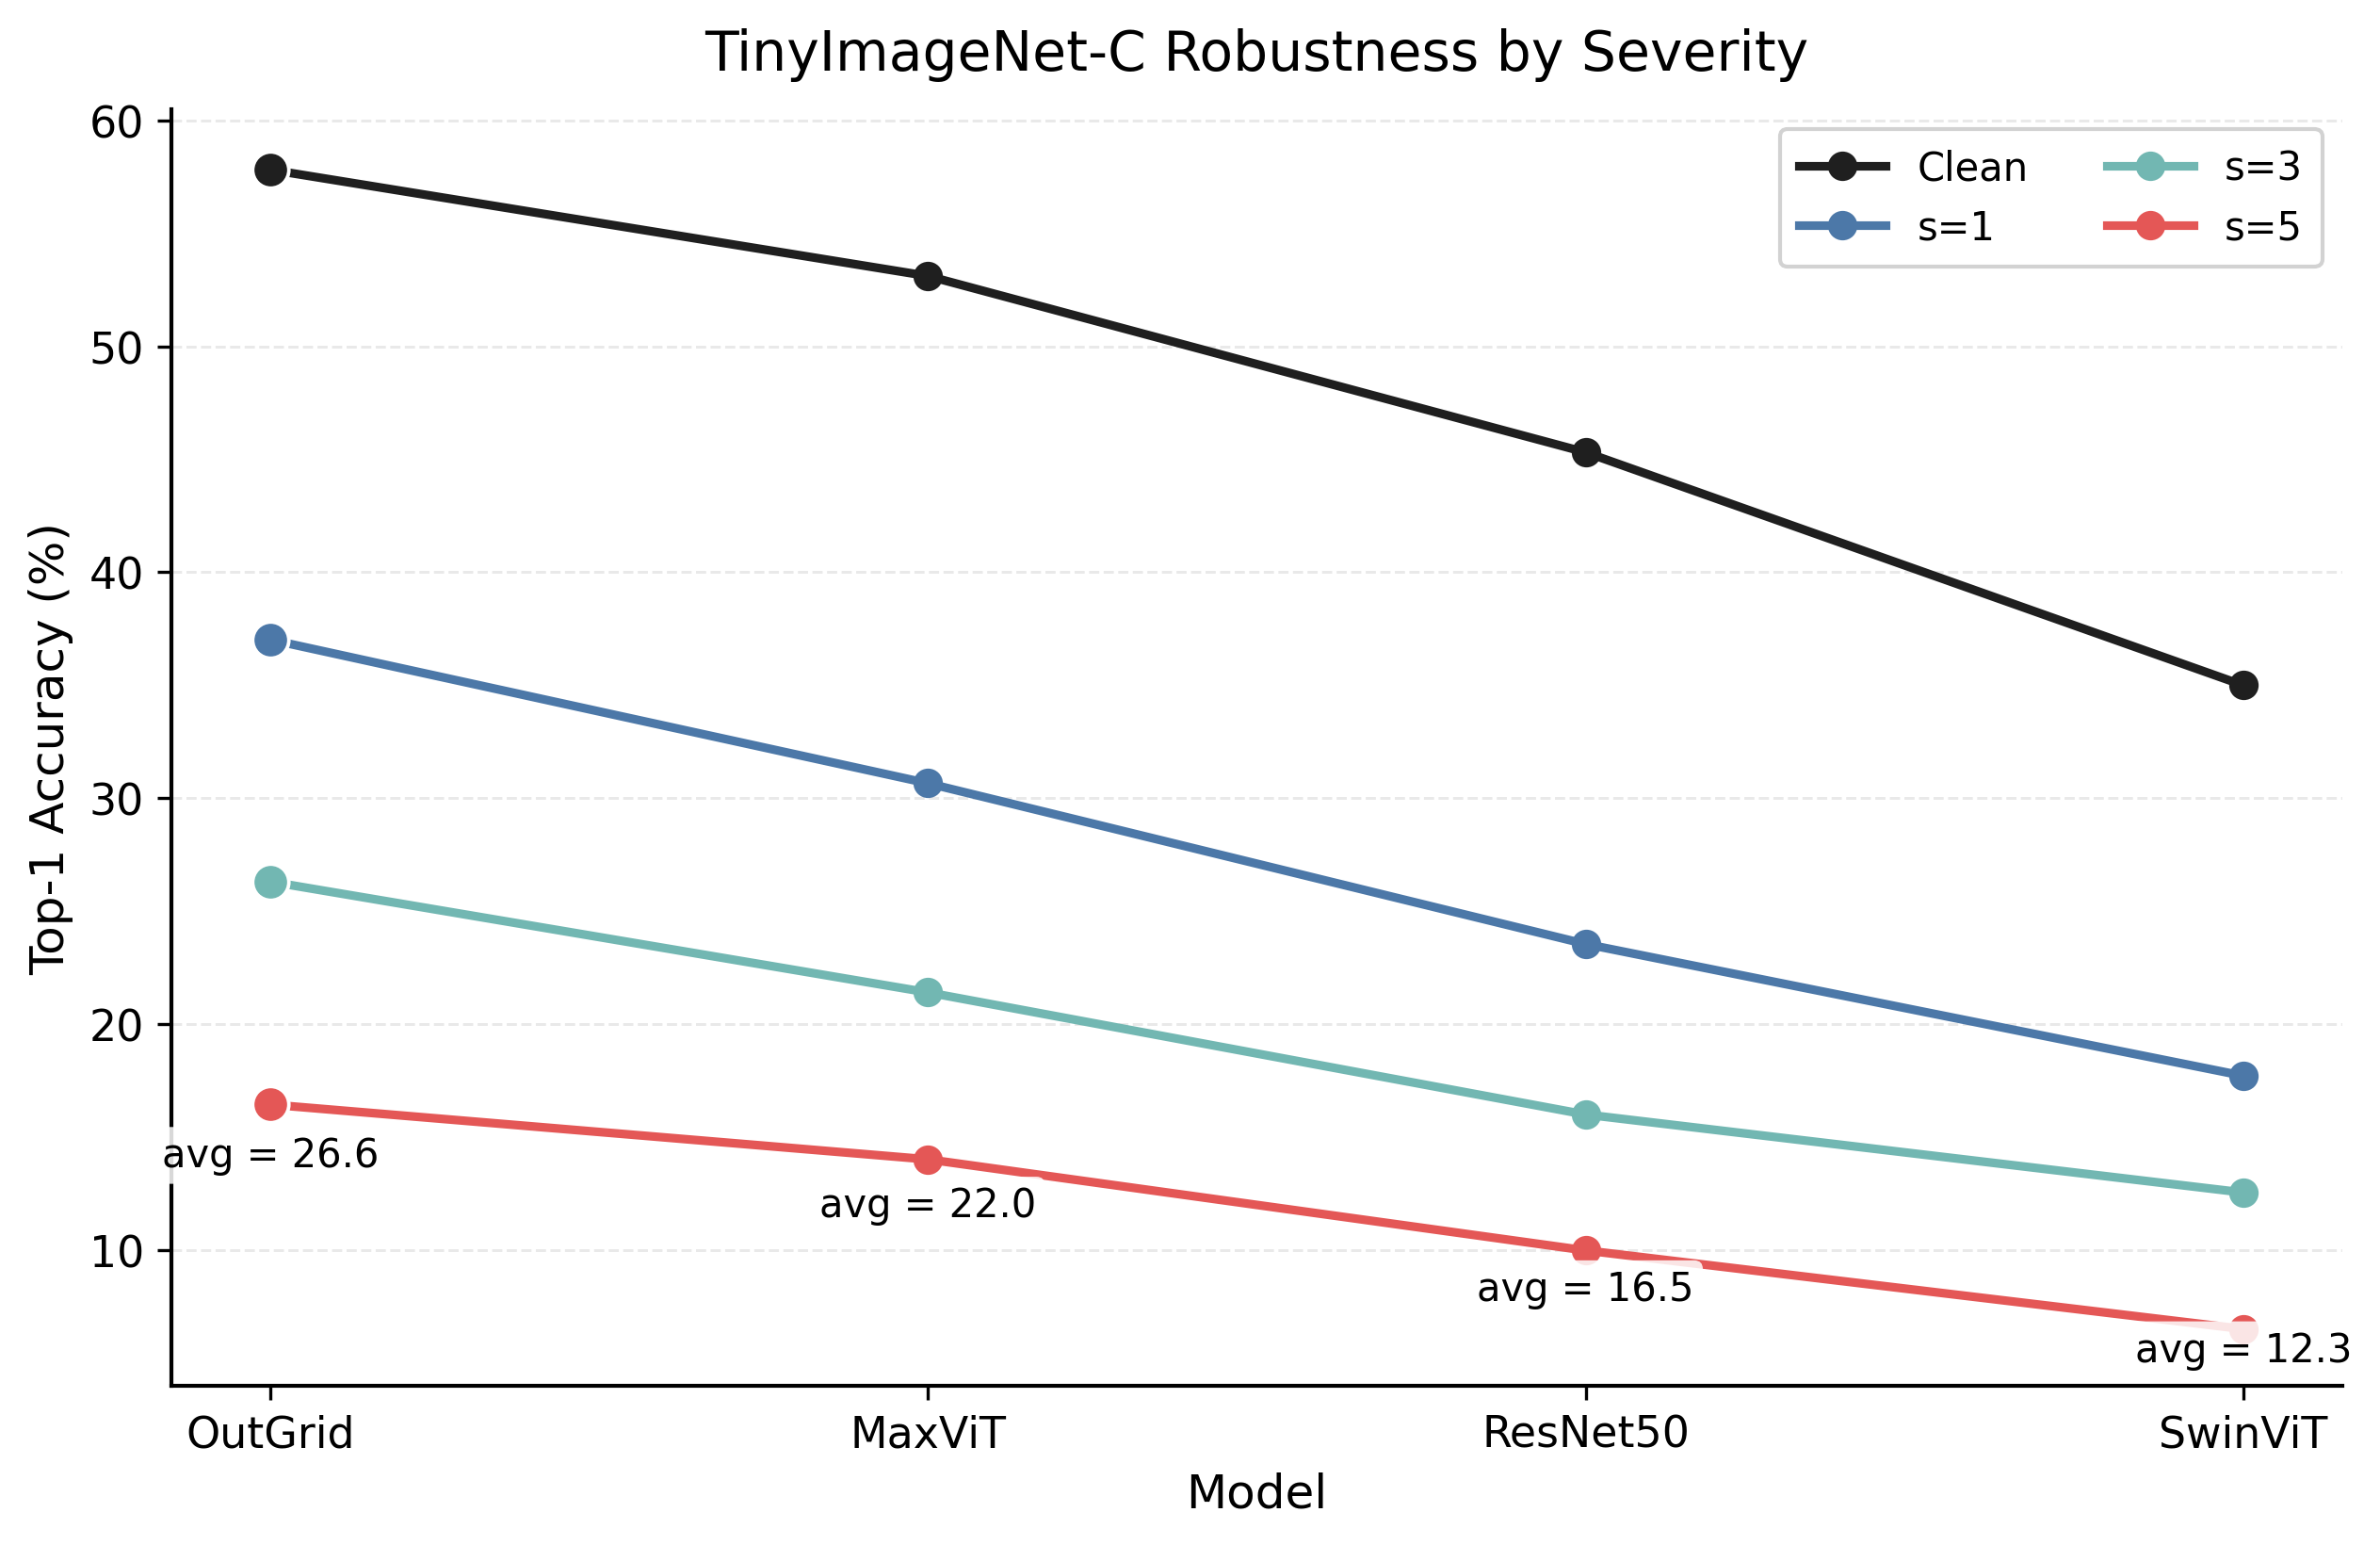

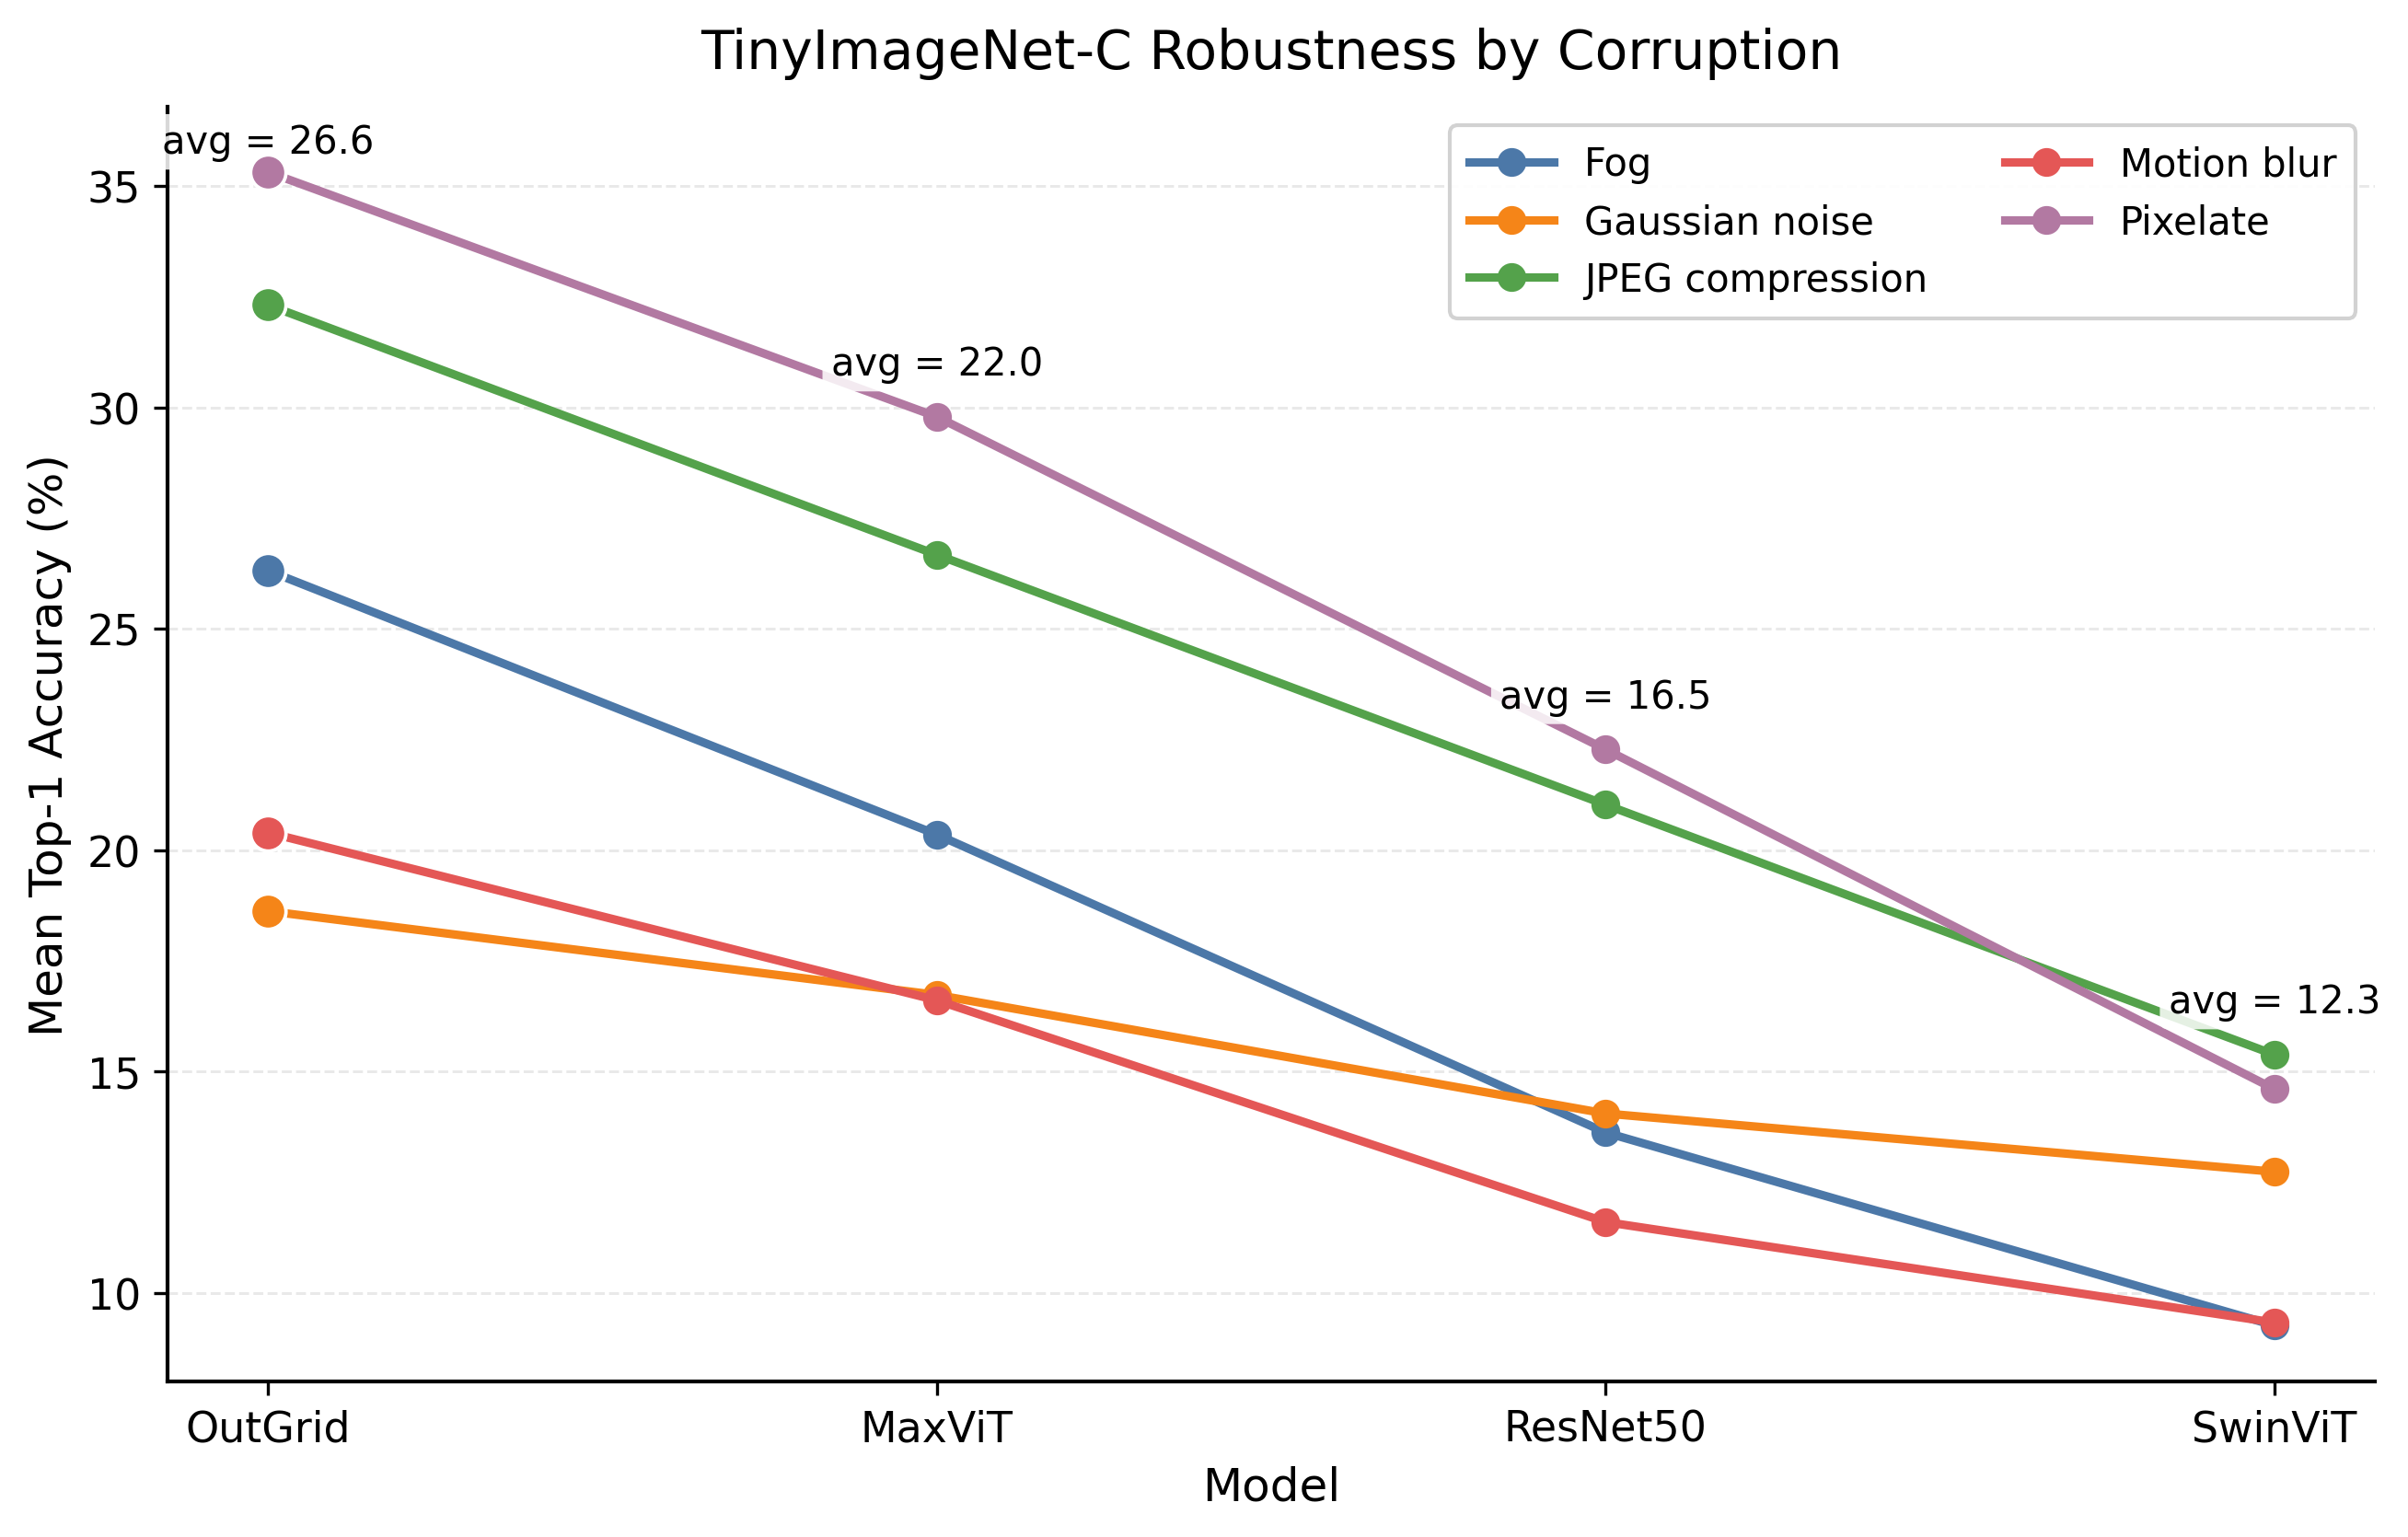

Saved figures in: C:\Users\alejo\OneDrive\Escritorio\Pablo\Profesional\Modelaje\Modelos de DL\outlook-grid-vision-transformer\graphs\paper_figures_tinyimagenetc_v2


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# =========================================================
# 1) DATA
# =========================================================

models = ["OutGrid", "MaxViT", "ResNet50", "SwinViT"]

severity_top1 = pd.DataFrame({
    "Model": models,
    "Clean": [57.81318681318681, 53.10989010989011, 45.30769230769231, 35.0],
    "s=1":   [37.02197802197802, 30.66373626373626, 23.55164835164835, 17.723076923076924],
    "s=3":   [26.31208791208791, 21.41098901098901, 16.00879120879121, 12.558241758241758],
    "s=5":   [16.450549450549453, 14.024175824175824, 9.995604395604396, 6.518681318681319],
})

corruption_top1 = pd.DataFrame({
    "Model": models,
    "Fog":              [26.315018315018317, 20.355311355311354, 13.626373626373626, 9.267399267399266],
    "Gaussian noise":   [18.626373626373628, 16.732600732600734, 14.054945054945057, 12.739926739926739],
    "JPEG compression": [32.315018315018314, 26.67399267399267, 21.02930402930403, 15.384615384615385],
    "Motion blur":      [20.399267399267398, 16.611721611721613, 11.604395604395606, 9.333333333333334],
    "Pixelate":         [35.31868131868132, 29.791208791208792, 22.278388278388277, 14.608058608058608],
})

overall_top1 = {
    "OutGrid": 26.594871794871793,
    "MaxViT": 22.032967032967033,
    "ResNet50": 16.51868131868132,
    "SwinViT": 12.266666666666667,
}

order = ["OutGrid", "MaxViT", "ResNet50", "SwinViT"]
severity_top1["Model"] = pd.Categorical(severity_top1["Model"], categories=order, ordered=True)
corruption_top1["Model"] = pd.Categorical(corruption_top1["Model"], categories=order, ordered=True)
severity_top1 = severity_top1.sort_values("Model").reset_index(drop=True)
corruption_top1 = corruption_top1.sort_values("Model").reset_index(drop=True)

outdir = Path("paper_figures_tinyimagenetc_v2")
outdir.mkdir(exist_ok=True)

# =========================================================
# 2) GLOBAL STYLE
# =========================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
})

# More paper-like palette
severity_colors = {
    "Clean": "#1f1f1f",   # almost black
    "s=1":   "#4C78A8",   # muted blue
    "s=3":   "#72B7B2",   # muted teal
    "s=5":   "#E45756",   # muted red
}

corruption_colors = {
    "Fog": "#4C78A8",
    "Gaussian noise": "#F58518",
    "JPEG compression": "#54A24B",
    "Motion blur": "#E45756",
    "Pixelate": "#B279A2",
}

def style_axis(ax):
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.28)
    ax.grid(False, axis="x")
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

# =========================================================
# 3) FIGURE 1: ROBUSTNESS BY SEVERITY
# =========================================================

fig1, ax1 = plt.subplots(figsize=(8.6, 5.6), dpi=300)
x = list(range(len(order)))
severity_cols = ["Clean", "s=1", "s=3", "s=5"]

for col in severity_cols:
    ax1.plot(
        x,
        severity_top1[col].values,
        marker="o",
        markersize=6.5,
        linewidth=2.2,
        color=severity_colors[col],
        label=col,
        zorder=3
    )

# highlight OutGrid subtly
outgrid_idx = order.index("OutGrid")
for col in severity_cols:
    ax1.scatter(
        [outgrid_idx],
        [severity_top1.loc[outgrid_idx, col]],
        s=85,
        color=severity_colors[col],
        edgecolor="white",
        linewidth=0.9,
        zorder=4
    )

# internal annotations for avg
# placed near bottom but INSIDE the panel
annotation_y = [14.2, 12.0, 8.3, 5.6]
for i, m in enumerate(order):
    ax1.text(
        i,
        annotation_y[i],
        f"avg = {overall_top1[m]:.1f}",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="none", alpha=0.85)
    )

ax1.set_xticks(x)
ax1.set_xticklabels(order)
ax1.set_ylabel("Top-1 Accuracy (%)")
ax1.set_xlabel("Model")
ax1.set_title("TinyImageNet-C Robustness by Severity", pad=10)

ax1.set_ylim(4, 60.5)
style_axis(ax1)

leg1 = ax1.legend(
    loc="upper right",
    ncol=2,
    frameon=True,
    handlelength=2.2,
    borderpad=0.5
)
leg1.get_frame().set_alpha(0.95)
leg1.get_frame().set_edgecolor("#d0d0d0")

fig1.tight_layout()
fig1.savefig(outdir / "tinyimagenetc_severity_top1_paper.png")
fig1.savefig(outdir / "tinyimagenetc_severity_top1_paper.pdf")

# =========================================================
# 4) FIGURE 2: ROBUSTNESS BY CORRUPTION TYPE
# =========================================================

fig2, ax2 = plt.subplots(figsize=(8.9, 5.7), dpi=300)

corr_cols = ["Fog", "Gaussian noise", "JPEG compression", "Motion blur", "Pixelate"]

for col in corr_cols:
    ax2.plot(
        x,
        corruption_top1[col].values,
        marker="o",
        markersize=6.5,
        linewidth=2.2,
        color=corruption_colors[col],
        label=col,
        zorder=3
    )

# highlight OutGrid subtly
for col in corr_cols:
    ax2.scatter(
        [outgrid_idx],
        [corruption_top1.loc[outgrid_idx, col]],
        s=85,
        color=corruption_colors[col],
        edgecolor="white",
        linewidth=0.9,
        zorder=4
    )

# put averages INSIDE panel, close to top but not cut
avg_y = []
for i in range(len(order)):
    local_max = corruption_top1.iloc[i, 1:].max()
    y = min(local_max + 1.2, 36.0)
    avg_y.append(y)

for i, m in enumerate(order):
    ax2.text(
        i,
        avg_y[i],
        f"avg = {overall_top1[m]:.1f}",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="none", alpha=0.85)
    )

ax2.set_xticks(x)
ax2.set_xticklabels(order)
ax2.set_ylabel("Mean Top-1 Accuracy (%)")
ax2.set_xlabel("Model")
ax2.set_title("TinyImageNet-C Robustness by Corruption", pad=10)

ax2.set_ylim(8, 36.8)
style_axis(ax2)

leg2 = ax2.legend(
    loc="upper right",
    ncol=2,
    frameon=True,
    handlelength=2.2,
    borderpad=0.5
)
leg2.get_frame().set_alpha(0.95)
leg2.get_frame().set_edgecolor("#d0d0d0")

fig2.tight_layout()
fig2.savefig(outdir / "tinyimagenetc_corruption_top1_paper.png")
fig2.savefig(outdir / "tinyimagenetc_corruption_top1_paper.pdf")

plt.show()

print(f"Saved figures in: {outdir.resolve()}")

In [5]:
import numpy as np 

arr = np.array([0.5,1.8,-2.3,0.9])
m1 = arr.mean()
m2 = arr.var() + (m1 ** 2)

m2 - (m1) **2 

2.346875